# Autoformer – PM2.5 Future Forecast

This notebook loads the **saved Autoformer checkpoint** and predicts the next **24 hours** of PM2.5 concentration for Toronto Downtown.

## What data does the model need?

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `seq_len` | **96 hours** | The look-back window fed to the encoder — the past **4 days** of hourly readings |
| `label_len` | **48 hours** | The decoder start token — the last **2 days** of that window are repeated into the decoder |
| `pred_len` | **24 hours** | How many hours ahead the model predicts |

So the minimum you need is **the most recent 96 consecutive hourly readings** of 4 variables:
1. `PM_ppb` – PM2.5 concentration
2. `Temp (°C)` – air temperature
3. `Rel Hum (%)` – relative humidity
4. `Wind Spd (km/h)` – wind speed

The notebook below pulls those automatically from the cleaned dataset.

In [1]:
import sys, os

# ── Path setup ────────────────────────────────────────────────────────────────
# Works whether Jupyter is launched from the project root OR from autoformer/
_cwd = os.path.abspath('')
if os.path.basename(_cwd) == 'autoformer':
    NOTEBOOK_DIR = _cwd
    PROJECT_ROOT = os.path.dirname(_cwd)
else:
    # CWD is project root (most common: 'jupyter notebook' from root)
    NOTEBOOK_DIR = os.path.join(_cwd, 'autoformer')
    PROJECT_ROOT = _cwd
sys.path.insert(0, NOTEBOOK_DIR)             # so 'from models.Autoformer import Model' works

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from sklearn.preprocessing import StandardScaler

from models.Autoformer import Model

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print('Imports OK')

Imports OK


## 1 · Load the checkpoint and rebuild the model

In [2]:
CHECKPOINT = os.path.join(NOTEBOOK_DIR, 'saved_models', 'autoformer_pm25_best.pth')

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)

cfg = checkpoint['configs']
print('Checkpoint loaded — trained for', checkpoint['epoch'], 'epochs')
print('Val loss at save:', round(checkpoint['val_loss'], 5))
print()
print('Model config:')
for k, v in cfg.items():
    print(f'  {k:12s} = {v}')

Checkpoint loaded — trained for 9 epochs
Val loss at save: 0.79242

Model config:
  seq_len      = 96
  label_len    = 48
  pred_len     = 24
  enc_in       = 4
  dec_in       = 4
  c_out        = 4
  d_model      = 64
  n_heads      = 4
  e_layers     = 2
  d_layers     = 1
  d_ff         = 256
  moving_avg   = 25
  factor       = 3
  embed        = timeF
  freq         = h
  activation   = gelu


In [3]:
# ── Rebuild Configs from the saved dict ─────────────────────────────────────
# Defaults for any values not stored in the checkpoint dict
DEFAULTS = {
    'dropout':          0.05,
    'output_attention': False,
}

class Configs:
    pass

configs = Configs()
for k, v in DEFAULTS.items():          # set defaults first
    setattr(configs, k, v)
for k, v in cfg.items():               # checkpoint values override
    setattr(configs, k, v)

# ── Rebuild and load weights ─────────────────────────────────────────────────
model = Model(configs).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Model ready — {total_params:,} parameters — device: {device}')

# ── Restore the scaler from the saved mean/scale ─────────────────────────────
scaler = StandardScaler()
scaler.mean_  = checkpoint['scaler_mean']
scaler.scale_ = checkpoint['scaler_scale']
scaler.var_   = scaler.scale_ ** 2
scaler.n_features_in_ = 4
print('Scaler restored — features: PM_ppb | Temp (°C) | Rel Hum (%) | Wind Spd (km/h)')

Model ready — 168,196 parameters — device: cpu
Scaler restored — features: PM_ppb | Temp (°C) | Rel Hum (%) | Wind Spd (km/h)


## 2 · Load the dataset and pick the look-back window

We take the **last 96 rows** of the cleaned CSV.  
Change `ANCHOR_DATETIME` below to forecast from any historical point instead.

In [4]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'data_clean',
                         'cleaned_data_toronto_downtown.csv')

FEATURES  = ['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)']

df = pd.read_csv(DATA_PATH, low_memory=False)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors='coerce').ffill().bfill()
df = df.dropna(subset=FEATURES).reset_index(drop=True)

print(f'Dataset: {len(df):,} hourly rows')
print(f'Range  : {df["Datetime"].iloc[0]}  →  {df["Datetime"].iloc[-1]}')

Dataset: 56,493 hourly rows
Range  : 2019-06-22 00:00:00  →  2025-12-31 23:00:00


In [5]:
# ── Choose the anchor point ──────────────────────────────────────────────────
# Set ANCHOR_DATETIME to a specific timestamp to forecast from that point, e.g.:
#   ANCHOR_DATETIME = '2025-08-15 18:00:00'
# Leave as None to use the very last available row in the dataset.

ANCHOR_DATETIME = None

SEQ_LEN   = configs.seq_len    # 96
LABEL_LEN = configs.label_len  # 48
PRED_LEN  = configs.pred_len   # 24

if ANCHOR_DATETIME is None:
    anchor_idx = len(df) - 1
else:
    anchor_idx = df.index[df['Datetime'] == pd.Timestamp(ANCHOR_DATETIME)][0]

# The encoder window: rows [anchor_idx - SEQ_LEN + 1 … anchor_idx]
enc_end   = anchor_idx + 1
enc_start = enc_end - SEQ_LEN

assert enc_start >= 0, f'Not enough history: need {SEQ_LEN} rows before the anchor.'

window_df = df.iloc[enc_start:enc_end].copy()
anchor_dt = df['Datetime'].iloc[anchor_idx]

print(f'Encoder window : {window_df["Datetime"].iloc[0]}  →  {window_df["Datetime"].iloc[-1]}')
print(f'Forecast from  : {anchor_dt}')
print(f'Forecast to    : {anchor_dt + pd.Timedelta(hours=PRED_LEN)}')

Encoder window : 2025-12-28 00:00:00  →  2025-12-31 23:00:00
Forecast from  : 2025-12-31 23:00:00
Forecast to    : 2026-01-01 23:00:00


## 3 · Build model inputs

```
x_enc      [1, 96, 4]   ← scaled past 96-hour readings (encoder)
x_mark_enc [1, 96, 4]   ← time features for those 96 hours
x_dec      [1, 72, 4]   ← last 48h (label) + 24h zeros  (decoder start token)
x_mark_dec [1, 72, 4]   ← time features for decoder period (past 48h + future 24h)
```

In [6]:
def time_features(dt_series: pd.Series) -> np.ndarray:
    """Normalised hourly time features in [-0.5, 0.5]: hour, weekday, day, day-of-year."""
    dt = pd.DatetimeIndex(dt_series)
    return np.column_stack([
        dt.hour       / 23.0 - 0.5,
        dt.dayofweek  /  6.0 - 0.5,
        (dt.day - 1)  / 30.0 - 0.5,
        (dt.dayofyear - 1) / 365.0 - 0.5,
    ]).astype(np.float32)

# ── Encoder inputs ───────────────────────────────────────────────────────────
raw_enc  = window_df[FEATURES].values.astype(np.float32)
scaled   = scaler.transform(raw_enc)                       # [96, 4]

x_enc      = torch.FloatTensor(scaled).unsqueeze(0).to(device)              # [1, 96, 4]
x_mark_enc = torch.FloatTensor(
    time_features(window_df['Datetime'])
).unsqueeze(0).to(device)                                                    # [1, 96, 4]

# ── Decoder time marks (last 48 real hours + next 24 future hours) ───────────
dec_datetimes = pd.date_range(
    start = anchor_dt - pd.Timedelta(hours=LABEL_LEN - 1),
    periods = LABEL_LEN + PRED_LEN,
    freq = 'h'
)
x_mark_dec = torch.FloatTensor(
    time_features(pd.Series(dec_datetimes))
).unsqueeze(0).to(device)                                                    # [1, 72, 4]

# x_dec only provides its shape to the model (decoder init comes from x_enc decomposition)
x_dec = torch.zeros(1, LABEL_LEN + PRED_LEN, 4).to(device)                 # [1, 72, 4]

future_datetimes = pd.date_range(
    start  = anchor_dt + pd.Timedelta(hours=1),
    periods = PRED_LEN,
    freq   = 'h'
)

print('Inputs ready')
print(f'  x_enc      : {tuple(x_enc.shape)}')
print(f'  x_mark_enc : {tuple(x_mark_enc.shape)}')
print(f'  x_dec      : {tuple(x_dec.shape)}')
print(f'  x_mark_dec : {tuple(x_mark_dec.shape)}')

Inputs ready
  x_enc      : (1, 96, 4)
  x_mark_enc : (1, 96, 4)
  x_dec      : (1, 72, 4)
  x_mark_dec : (1, 72, 4)


## 4 · Run inference

In [7]:
with torch.no_grad():
    output = model(x_enc, x_mark_enc, x_dec, x_mark_dec)   # [1, 24, 4]

# Inverse-scale PM2.5 (column 0)
pred_scaled = output[0, :, 0].cpu().numpy()                # [24]
dummy       = np.zeros((PRED_LEN, 4), dtype=np.float32)
dummy[:, 0] = pred_scaled
pred_pm25   = scaler.inverse_transform(dummy)[:, 0]         # ppb

forecast_df = pd.DataFrame({
    'Datetime'         : future_datetimes,
    'PM2.5_pred (ppb)' : pred_pm25,
})
print('24-hour PM2.5 Forecast')
print('=' * 34)
print(forecast_df.to_string(index=False))

24-hour PM2.5 Forecast
           Datetime  PM2.5_pred (ppb)
2026-01-01 00:00:00          3.874787
2026-01-01 01:00:00          4.000023
2026-01-01 02:00:00          4.041479
2026-01-01 03:00:00          4.105064
2026-01-01 04:00:00          4.027193
2026-01-01 05:00:00          3.953338
2026-01-01 06:00:00          3.668143
2026-01-01 07:00:00          3.183864
2026-01-01 08:00:00          3.207519
2026-01-01 09:00:00          3.614702
2026-01-01 10:00:00          3.757535
2026-01-01 11:00:00          4.180667
2026-01-01 12:00:00          4.098641
2026-01-01 13:00:00          4.705725
2026-01-01 14:00:00          5.179067
2026-01-01 15:00:00          5.169272
2026-01-01 16:00:00          5.470888
2026-01-01 17:00:00          5.600338
2026-01-01 18:00:00          5.621282
2026-01-01 19:00:00          5.834775
2026-01-01 20:00:00          6.019246
2026-01-01 21:00:00          5.997859
2026-01-01 22:00:00          6.087094
2026-01-01 23:00:00          6.945508


## 5 · Plot 1 — 24-hour forecast with look-back context

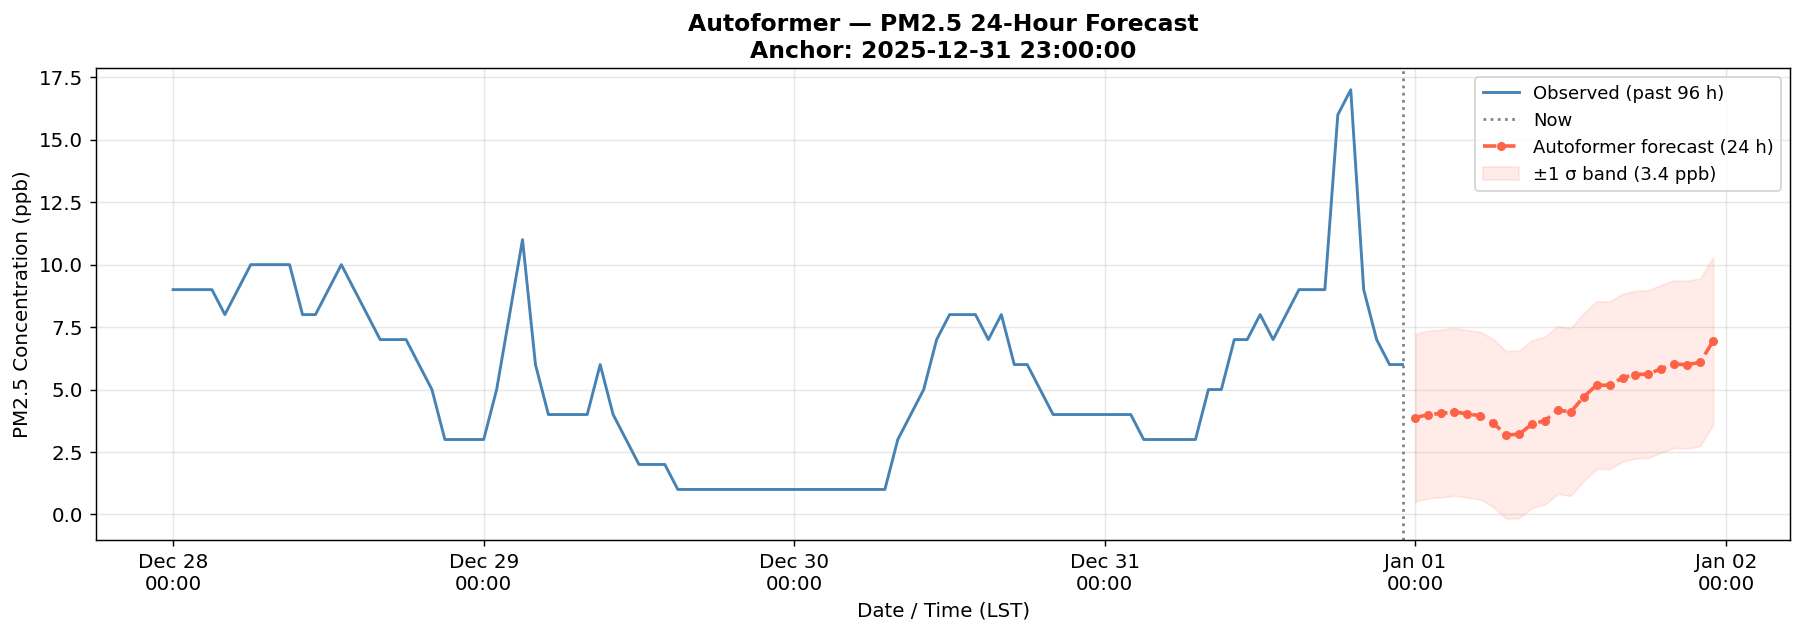

In [8]:
# Inverse-scale all 96 look-back PM2.5 values for context
dummy_hist        = np.zeros((SEQ_LEN, 4), dtype=np.float32)
dummy_hist[:, 0]  = scaled[:, 0]
history_pm25      = scaler.inverse_transform(dummy_hist)[:, 0]

fig, ax = plt.subplots(figsize=(14, 5))

# ── History (past 96 hours) ──────────────────────────────────────────────────
ax.plot(
    window_df['Datetime'], history_pm25,
    color='steelblue', linewidth=1.6, label='Observed (past 96 h)'
)

# ── Vertical divider at "now" ─────────────────────────────────────────────────
ax.axvline(anchor_dt, color='gray', linestyle=':', linewidth=1.5, label='Now')

# ── Forecast (next 24 hours) ─────────────────────────────────────────────────
ax.plot(
    future_datetimes, pred_pm25,
    color='tomato', linewidth=2, linestyle='--',
    marker='o', markersize=4, label='Autoformer forecast (24 h)'
)

# ── Confidence band (±1 std of historical residuals as a rough envelope) ─────
hist_std = history_pm25.std()
ax.fill_between(
    future_datetimes,
    pred_pm25 - hist_std,
    pred_pm25 + hist_std,
    color='tomato', alpha=0.12, label=f'±1 σ band ({hist_std:.1f} ppb)'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.set_title(
    f'Autoformer — PM2.5 24-Hour Forecast\nAnchor: {anchor_dt}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Date / Time (LST)', fontsize=11)
ax.set_ylabel('PM2.5 Concentration (ppb)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 6 · Plot 2 — Hourly forecast bar chart with colour-coded AQI bands

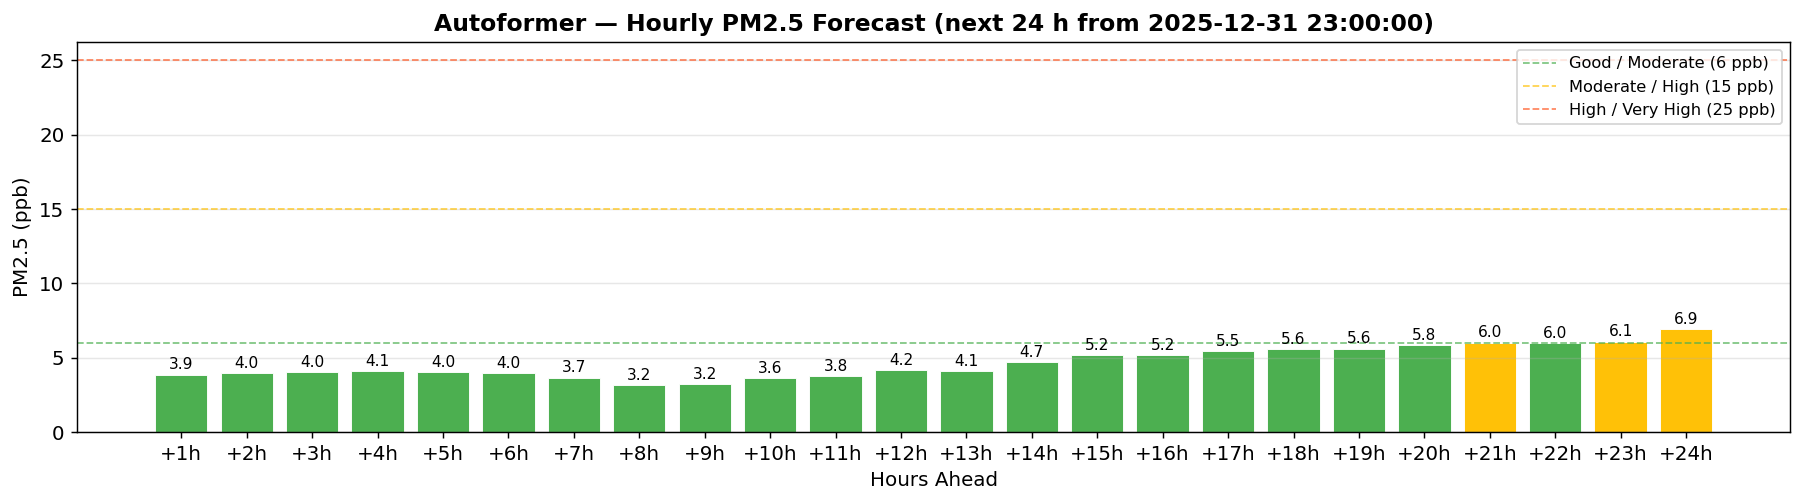

In [9]:
# Ontario AQHI PM2.5 breakpoints (ppb ≈ µg/m³ × 0.55 for PM2.5)
# Using raw ppb thresholds scaled from µg/m³ (1 ppb PM2.5 ≈ 1.81 µg/m³)
# Rough AQHI colouring: Good <6 ppb | Moderate 6–15 ppb | High >15 ppb
def pm25_colour(val):
    if val < 6:   return '#4CAF50'   # green  – Good
    if val < 15:  return '#FFC107'   # amber  – Moderate
    if val < 25:  return '#FF5722'   # orange – High
    return '#B71C1C'                 # red    – Very High

colours = [pm25_colour(v) for v in pred_pm25]
hours   = [f'+{i+1}h' for i in range(PRED_LEN)]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(hours, pred_pm25, color=colours, edgecolor='white', linewidth=0.5)

# Value labels
for bar, val in zip(bars, pred_pm25):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f'{val:.1f}', ha='center', va='bottom', fontsize=8.5
    )

# Reference lines
ax.axhline(6,  color='#4CAF50', linestyle='--', linewidth=1, alpha=0.7, label='Good / Moderate (6 ppb)')
ax.axhline(15, color='#FFC107', linestyle='--', linewidth=1, alpha=0.7, label='Moderate / High (15 ppb)')
ax.axhline(25, color='#FF5722', linestyle='--', linewidth=1, alpha=0.7, label='High / Very High (25 ppb)')

ax.set_title(
    f'Autoformer — Hourly PM2.5 Forecast (next 24 h from {anchor_dt})',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Hours Ahead', fontsize=11)
ax.set_ylabel('PM2.5 (ppb)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## 7 · Plot 3 — Full test-set evaluation with ±1 σ band

Runs the model across the entire held-out **test set** (last 20% of the dataset, matching the train/val split used during training).  
Shows **H+4** (4 hours ahead) predicted vs actual PM2.5 with a rolling ±1 σ confidence band.

Test-set samples : 11,275
Running H+1 inference … done

Test-set H+4  →  MAE = 4.518 ppb  |  RMSE = 7.042 ppb


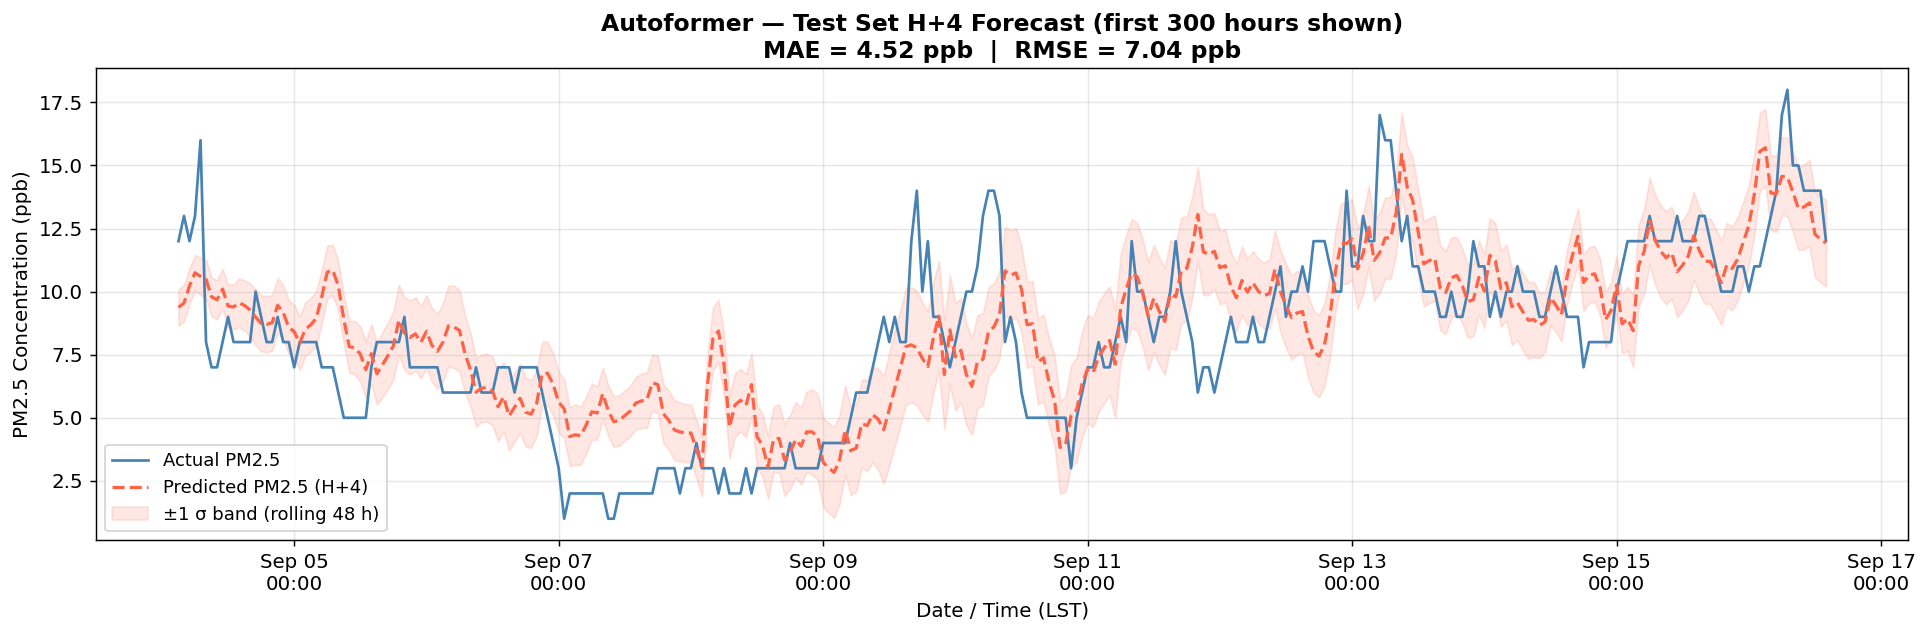

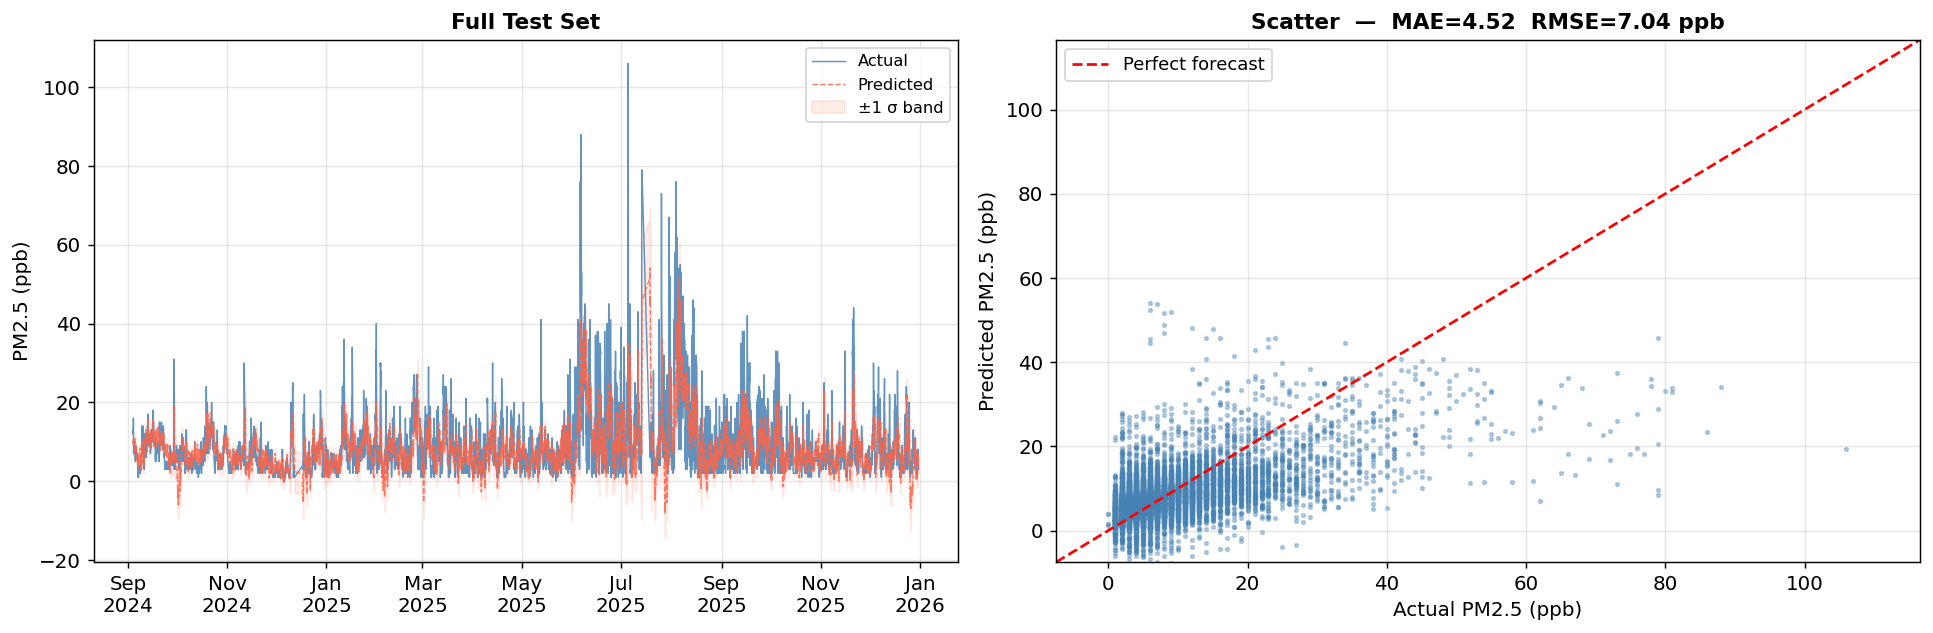

In [10]:
# ── Re-scale all data (same pipeline as training) ────────────────────────────
full_data_scaled = scaler.transform(
    df[FEATURES].values.astype(np.float32)
)
all_time_marks = time_features(df['Datetime'])

# ── Reproduce the 80/20 temporal split ───────────────────────────────────────
n_total  = len(df) - SEQ_LEN - PRED_LEN + 1
n_train  = int(0.8 * n_total)
val_indices = range(n_train, n_total)

print(f'Test-set samples : {len(val_indices):,}')
print(f'Running H+1 inference … ', end='', flush=True)

# ── Batch inference over the entire test set ─────────────────────────────────
BATCH = 128
test_preds_scaled   = []   # H+1 prediction (scaled)
test_actuals_scaled = []   # H+1 ground truth (scaled)
test_datetimes      = []   # timestamp of the predicted hour

for start in range(n_train, n_total, BATCH):
    end = min(start + BATCH, n_total)
    B   = end - start

    enc_arr  = np.stack([full_data_scaled[i : i + SEQ_LEN]               for i in range(start, end)])
    menc_arr = np.stack([all_time_marks  [i : i + SEQ_LEN]               for i in range(start, end)])
    dec_arr  = np.zeros((B, LABEL_LEN + PRED_LEN, 4), dtype=np.float32)
    mdec_arr = np.stack([all_time_marks  [i + SEQ_LEN - LABEL_LEN :
                                          i + SEQ_LEN + PRED_LEN]        for i in range(start, end)])
    y_arr    = np.stack([full_data_scaled[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN]
                         for i in range(start, end)])

    with torch.no_grad():
        out = model(
            torch.FloatTensor(enc_arr).to(device),
            torch.FloatTensor(menc_arr).to(device),
            torch.FloatTensor(dec_arr).to(device),
            torch.FloatTensor(mdec_arr).to(device),
        )  # [B, 24, 4]

    test_preds_scaled.append(out[:, 3, 0].cpu().numpy())     # H+4, PM2.5 channel
    test_actuals_scaled.append(y_arr[:, 3, 0])               # H+4, PM2.5 channel
    test_datetimes.extend(df['Datetime'].iloc[i + SEQ_LEN + 3].to_pydatetime()
                          for i in range(start, end))

print('done')

# ── Inverse-scale PM2.5 ───────────────────────────────────────────────────────
def inv(arr_1d):
    d = np.zeros((len(arr_1d), 4), dtype=np.float32)
    d[:, 0] = arr_1d
    return scaler.inverse_transform(d)[:, 0]

test_preds   = inv(np.concatenate(test_preds_scaled))    # [N]
test_actuals = inv(np.concatenate(test_actuals_scaled))  # [N]
test_dt      = pd.DatetimeIndex(test_datetimes)

mae_ts  = np.mean(np.abs(test_preds - test_actuals))
rmse_ts = math.sqrt(np.mean((test_preds - test_actuals) ** 2))
print(f'\nTest-set H+4  →  MAE = {mae_ts:.3f} ppb  |  RMSE = {rmse_ts:.3f} ppb')

# ── Rolling ±1 σ band  (48-hour window) ──────────────────────────────────────
WIN = 48
pred_series = pd.Series(test_preds, index=test_dt)
roll_std    = pred_series.rolling(WIN, min_periods=1, center=True).std().fillna(pred_series.std())

# ── Plot 1 of 2 — zoomed 300-step window (first 300 h of test set) ────────────
N_ZOOM = 300
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(test_dt[:N_ZOOM], test_actuals[:N_ZOOM],
        color='steelblue', linewidth=1.5, label='Actual PM2.5')

ax.plot(test_dt[:N_ZOOM], test_preds[:N_ZOOM],
        color='tomato', linewidth=1.8, linestyle='--', label='Predicted PM2.5 (H+4)')

sigma = roll_std.values[:N_ZOOM]
ax.fill_between(
    test_dt[:N_ZOOM],
    test_preds[:N_ZOOM] - sigma,
    test_preds[:N_ZOOM] + sigma,
    color='tomato', alpha=0.15,
    label=f'±1 σ band (rolling {WIN} h)'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.set_title(
    f'Autoformer — Test Set H+4 Forecast (first {N_ZOOM} hours shown)\n'
    f'MAE = {mae_ts:.2f} ppb  |  RMSE = {rmse_ts:.2f} ppb',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Date / Time (LST)', fontsize=11)
ax.set_ylabel('PM2.5 Concentration (ppb)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# ── Plot 2 of 2 — full test set + scatter ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: full test-set time series
ax = axes[0]
ax.plot(test_dt, test_actuals, color='steelblue', linewidth=0.8,
        alpha=0.85, label='Actual')
ax.plot(test_dt, test_preds,   color='tomato',    linewidth=0.8,
        linestyle='--', alpha=0.85, label='Predicted')
ax.fill_between(
    test_dt,
    test_preds - roll_std.values,
    test_preds + roll_std.values,
    color='tomato', alpha=0.12, label=f'±1 σ band'
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.set_title('Full Test Set', fontsize=12, fontweight='bold')
ax.set_ylabel('PM2.5 (ppb)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: scatter
ax2 = axes[1]
lo = min(test_actuals.min(), test_preds.min()) * 0.9
hi = max(test_actuals.max(), test_preds.max()) * 1.1
ax2.scatter(test_actuals, test_preds, s=4, color='steelblue', alpha=0.35)
ax2.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect forecast')
ax2.set_xlim(lo, hi); ax2.set_ylim(lo, hi)
ax2.set_xlabel('Actual PM2.5 (ppb)', fontsize=11)
ax2.set_ylabel('Predicted PM2.5 (ppb)', fontsize=11)
ax2.set_title(f'Scatter  —  MAE={mae_ts:.2f}  RMSE={rmse_ts:.2f} ppb',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8 · Forecast from custom input data

If you have fresh sensor readings that are **not** in the CSV, fill in the table below.  
You need **96 consecutive hourly rows** — the most recent 4 days.

In [11]:
# ── Uncomment and fill in to use your own data ───────────────────────────────
# Change the date range and values to match your actual readings.
#
# custom_datetimes = pd.date_range('2026-01-01 00:00', periods=96, freq='h')
# custom_data = pd.DataFrame({
#     'Datetime'       : custom_datetimes,
#     'PM_ppb'         : [5.0] * 96,   # ← replace with real readings
#     'Temp (°C)'      : [3.0] * 96,
#     'Rel Hum (%)'    : [70.0] * 96,
#     'Wind Spd (km/h)': [12.0] * 96,
# })
#
# raw_custom   = custom_data[FEATURES].values.astype(np.float32)
# scaled_c     = scaler.transform(raw_custom)
# anchor_c     = custom_datetimes[-1]
#
# x_enc_c      = torch.FloatTensor(scaled_c).unsqueeze(0).to(device)
# x_mark_enc_c = torch.FloatTensor(time_features(pd.Series(custom_datetimes))).unsqueeze(0).to(device)
#
# dec_dt_c     = pd.date_range(anchor_c - pd.Timedelta(hours=LABEL_LEN-1),
#                              periods=LABEL_LEN+PRED_LEN, freq='h')
# x_mark_dec_c = torch.FloatTensor(time_features(pd.Series(dec_dt_c))).unsqueeze(0).to(device)
# x_dec_c      = torch.zeros(1, LABEL_LEN + PRED_LEN, 4).to(device)
#
# with torch.no_grad():
#     out_c = model(x_enc_c, x_mark_enc_c, x_dec_c, x_mark_dec_c)
#
# dummy_c = np.zeros((PRED_LEN, 4), dtype=np.float32)
# dummy_c[:, 0] = out_c[0, :, 0].cpu().numpy()
# pred_c = scaler.inverse_transform(dummy_c)[:, 0]
# future_c = pd.date_range(anchor_c + pd.Timedelta(hours=1), periods=PRED_LEN, freq='h')
#
# pd.DataFrame({'Datetime': future_c, 'PM2.5_pred (ppb)': pred_c})

print('Custom-data cell is ready — uncomment the lines above and fill in your readings.')

Custom-data cell is ready — uncomment the lines above and fill in your readings.
